# Perceptron Trick Visualization

This notebook demonstrates how the Perceptron learning algorithm works on a linearly separable dataset.

We implement the perceptron from scratch using NumPy and compare its decision boundary with Logistic Regression from scikit-learn.

In [11]:
from sklearn.datasets import make_classification
import numpy as np
X, y = make_classification(n_samples=100, n_features=2, n_informative=1,n_redundant=0,
                           n_classes=2, n_clusters_per_class=1, random_state=41,hypercube=False,class_sep=10)

In [12]:
import matplotlib.pyplot as plt

# Visualizing the Dataset

We plot the generated dataset using a scatter plot.

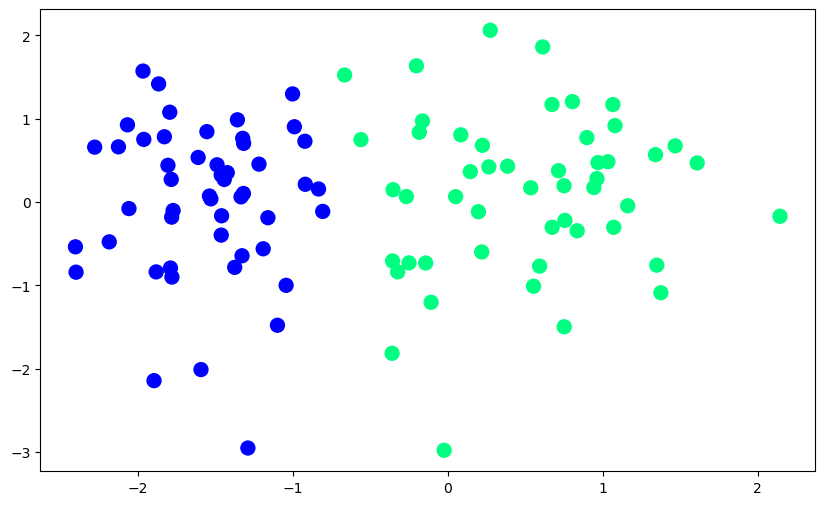

In [13]:
plt.figure(figsize=(10,6))
plt.scatter(X[:,0],X[:,1],c=y,cmap='winter',s=100)

# Implementing the Perceptron from Scratch

The perceptron learns a linear decision boundary of the form:
w1x1 + w2x2 + b = 0

In [17]:
def perceptron(X,y):
    X=np.insert(X,0,1,axis=1)
    weights=np.ones(X.shape[1])  #w0 w1 w2 all are 1
    lr=0.1

    for i in range(1000):
        j=np.random.randint(0,100)
        y_hat=step(np.dot(X[j],weights))
        weights=weights+lr*(y[j]-y_hat)*X[j]

    return weights[0],weights[1:]
    #returns intercept and coeff

In [18]:
def step(z):
    return 1 if z>0 else  0

In [19]:
intercept_,coef_ = perceptron(X,y)

In [20]:

print(coef_)
print(intercept_)

[1.35099036 0.02014163]
1.0


In [22]:
#finding the slope and intercept
m= -(coef_[0]/coef_[1])
b= -(intercept_/coef_[1])

In [23]:
x_input=np.linspace(-3,3,100) 
y_input=m*x_input+b

(-3.0, 2.0)

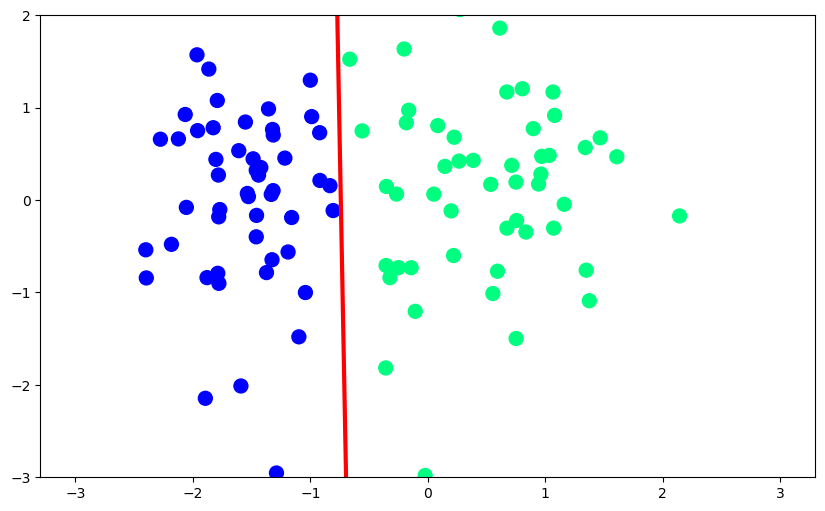

In [30]:
plt.figure(figsize=(10,6))
plt.plot(x_input,y_input,color='red',linewidth=3)
plt.scatter(X[:,0],X[:,1],c=y,cmap='winter',s=100)
plt.ylim(-3,2)

# Comparing with Logistic Regression

We compare the decision boundary learned by the perceptron with the decision boundary learned by Logistic Regression from scikit-learn.
This helps visualize the similarity between the two linear classifiers.

In [33]:

from sklearn.linear_model import LogisticRegression
lor = LogisticRegression()
lor.fit(X,y)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [34]:
m = -(lor.coef_[0][0]/lor.coef_[0][1])
b = -(lor.intercept_/lor.coef_[0][1])

In [35]:
x_input1 = np.linspace(-3,3,100)
y_input1 = m*x_input + b

(-3.0, 2.0)

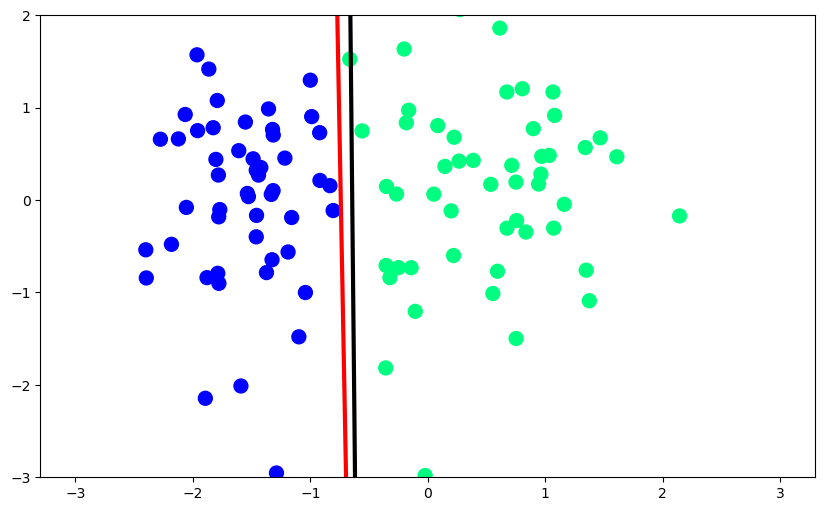

In [36]:

plt.figure(figsize=(10,6))
plt.plot(x_input,y_input,color='red',linewidth=3)
plt.plot(x_input1,y_input1,color='black',linewidth=3)
plt.scatter(X[:,0],X[:,1],c=y,cmap='winter',s=100)
plt.ylim(-3,2)